# Day 3 — CNNs: Networks That Understand Pixels

CNNs don't just process pixels; they **understand** them.

On Day 1 we fed MNIST images into our network as a flat list of 784 numbers. That works for tiny
greyscale digits, but it throws away the most important property of an image: **pixels that are close
together are related**. A cat's ear is a *local pattern* — edges, curves, textures — and it's still a
cat's ear whether it appears in the top-left or bottom-right of the photo.

**Convolutional Neural Networks (CNNs)** are built around exactly these two ideas:

- **Local patterns**: small filters (kernels) slide across the image, each learning to detect one
  pattern — an edge, a colour blob, eventually eyes and wheels
- **Translation invariance**: the *same* filter is reused at every position, so a pattern is
  recognised wherever it appears (and we need far fewer parameters than a fully-connected layer)

Today you will:

1. Understand **convolution** and **pooling**, the two building blocks of CNNs
2. Build and train a CNN on **CIFAR-10** — real colour photos in 10 classes
3. Upgrade your training workflow with **checkpoints** (and reuse Day 2's learning-curve skills)
4. Diagnose overfitting and fix it with the **Day 2 toolbox**
5. **See inside** the network: visualize the feature maps it learns
6. Stand on the shoulders of giants with **transfer learning**
7. Survey how CNNs power **object detection** and **face recognition**

Our dataset gets an upgrade too: CIFAR-10 — 60,000 32×32 *colour* images: planes, cars, birds, cats...

## CIFAR 10 Dataset

Files already downloaded and verified
Files already downloaded and verified


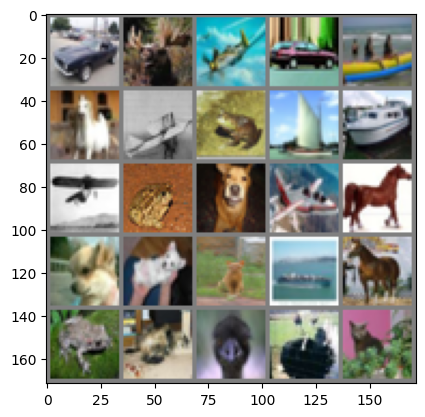

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Hyper-parameters 
num_epochs = 10 #changed to 2 later
batch_size = 32
learning_rate = 0.001

# dataset has PILImage images of range [0, 1]. 
# We transform them to Tensors of normalized range [-1, 1]
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(imgs):
    imgs = imgs / 2 + 0.5   # unnormalize
    npimgs = imgs.numpy()
    plt.imshow(np.transpose(npimgs, (1, 2, 0)))
    plt.show()

# one batch of random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
img_grid = torchvision.utils.make_grid(images[0:25], nrow=5)
imshow(img_grid)

# Kernel Convolution and MaxPooling
Kernel Convolution is a process that takes a kernel (usually square and of odd size) and slides it across an image to compute a new image (for blurring, edge detection etc) or feature map.

This process is not only for images, but can also be applied on 1D datasets (like time series). [This video](https://www.youtube.com/watch?v=KuXjwB4LzSA) explains the concept in more detail.

![conv](convolution.jpg)

Pooling is usually used in tandem with convolution as way to reduce the size of end result of each layer, which makes the computation fast, reduces memory and also prevents overfitting. Two common types of pooling layers are max pooling and average pooling.

![maxpool](maxpooling.png)

A typical Convolutional Neural Network consists of these types of layers, and ending with a fully connected/linear/dense layer to convert the end image into an output result (e.g. a class)

![cnn](cnn.png)

Let us build one such layer

*To better understand how these figures are gotten, check out the layer by layer examples in the model_dim_examples folder*


In [2]:
# Creating the Model
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 input image channel, 32 output channels, 3x3 square convolution
        self.conv1 = nn.Conv2d(3, 32, 3) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 64, 3)
        self.fc1 = nn.Linear(64*4*4, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # N, 3, 32, 32
        x = F.relu(self.conv1(x))   # -> N, 32, 30, 30
        x = self.pool(x)            # -> N, 32, 15, 15
        x = F.relu(self.conv2(x))   # -> N, 64, 13, 13
        x = self.pool(x)            # -> N, 64, 6, 6
        x = F.relu(self.conv3(x))   # -> N, 64, 4, 4
        x = torch.flatten(x, 1)     # -> N, 1024
        x = F.relu(self.fc1(x))     # -> N, 64
        x = self.fc2(x)             # -> N, 10
        return x

We could run the model as we did last week, training it as follows:

In [3]:
model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

n_total_steps = len(train_loader)
for epoch in range(num_epochs):

    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item()

    print(f'[{epoch + 1}] loss: {running_loss / n_total_steps:.3f}')

# Save the Model Weights
print('Finished Training')
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)

[1] loss: 1.488
[2] loss: 1.124
[3] loss: 0.965
[4] loss: 0.855
[5] loss: 0.779
[6] loss: 0.714
[7] loss: 0.662
[8] loss: 0.616
[9] loss: 0.574
[10] loss: 0.537
Finished Training


And testing it as follows (the second output is just to show you that the saved model and one run before exactly the same):

In [4]:
loaded_model = ConvNet()
loaded_model.load_state_dict(torch.load(PATH)) # it takes the loaded dictionary, not the path file itself
loaded_model.to(device)
loaded_model.eval()

with torch.no_grad():
    n_correct = 0
    n_correct2 = 0
    n_samples = len(test_loader.dataset)

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_correct += (predicted == labels).sum().item()

        outputs2 = loaded_model(images)
        _, predicted2 = torch.max(outputs2, 1)
        n_correct2 += (predicted2 == labels).sum().item()

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the model: {acc} %')

    acc = 100.0 * n_correct2 / n_samples
    print(f'Accuracy of the loaded model: {acc} %')

Accuracy of the model: 72.28 %
Accuracy of the loaded model: 72.28 %


But a better way exists.

# Training Function

Let's create a train_model function we can call instead, and have it do the following:
- run both datasets (train and validation/test)
- log the history of losses for both
- tell us how long training each epoch took
- save the model as a checkpoint so we can continue running it if the number of epochs were not enough

In [5]:
def train_model(train_dataset, val_dataset, num_epochs):
    
    model = ConvNet().to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # a dictionary to save the training and validation loss for each epoch
    history = dict(train=[], val=[])

    for epoch in range(num_epochs):
        model.train() # set the model to training mode
        ts = time.time() # initial time
        train_losses = []

        # Training loop
        for i, (images, labels) in enumerate(train_dataset):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_losses.append(loss.item())
        
        # Validation loop
        val_losses = []
        model = model.eval()

        with torch.no_grad():
            for i, (images, labels) in enumerate(val_dataset):
                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_losses.append(loss.item())

        te = time.time() # final time
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history['train'].append(train_loss)
        history['val'].append(val_loss) 
        
        print(f"Epoch: {epoch}  train loss: {train_loss}  val loss: {val_loss}  time: {te-ts} ")

    # create a checkpoint
    checkpoint = {
        'model': ConvNet(),
        'epoch': epoch + 1,
        'state_dict': model.state_dict(),
        'optimizer' : optimizer.state_dict()
        }

    return model.eval(), history, checkpoint  

Now let's run the model and see how it performs.

In [6]:
model, history, checkpoint = train_model(train_loader, test_loader, num_epochs)

Epoch: 0  train loss: 1.4827626002040797  val loss: 1.2811296487006898  time: 16.703413009643555 
Epoch: 1  train loss: 1.1155292041699854  val loss: 1.0533133099635188  time: 16.72130298614502 
Epoch: 2  train loss: 0.961642319623736  val loss: 0.9428131416582832  time: 16.686695098876953 
Epoch: 3  train loss: 0.8552541122059751  val loss: 0.8748736043517201  time: 16.681299924850464 
Epoch: 4  train loss: 0.7787698793510406  val loss: 0.8498415811755025  time: 16.672839164733887 
Epoch: 5  train loss: 0.7202624411287021  val loss: 0.8238434185996985  time: 16.640217065811157 
Epoch: 6  train loss: 0.6708554766037795  val loss: 0.8909623241081787  time: 16.61944007873535 
Epoch: 7  train loss: 0.6269526289524516  val loss: 0.8196085546725094  time: 16.581582069396973 
Epoch: 8  train loss: 0.5859295961781336  val loss: 0.8240596172146903  time: 16.696033716201782 
Epoch: 9  train loss: 0.5490588121454607  val loss: 0.856717817223491  time: 16.646517038345337 


With the returned history, we can plot out it's learning progression (learning curves):

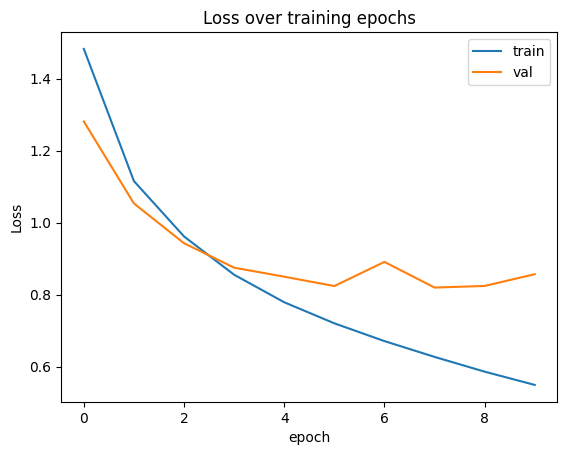

In [7]:
plt.plot(history['train'])
plt.plot(history['val'])
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.title('Loss over training epochs')
plt.legend(['train','val'])
plt.show();

**Checkpointing — recall Day 2.** On Day 2 we checkpointed a small MLP, then resumed it to extend its loss curve across two sessions. The idea is identical here, but the payoff is much bigger: CIFAR-10 CNN training is *slow*, so a checkpoint means an interrupted or not-yet-converged run can pick up exactly where it left off — optimizer state and all — instead of starting from epoch 0. Let's save one out.

In [8]:
CHECKPOINT_PATH = fr'./checkpoints/ConvNet_model_after_{checkpoint["epoch"]}_epochs_s.pth'
torch.save(checkpoint, CHECKPOINT_PATH)

Here's a training loop that is similar to the one above, except that it takes in the checkpoint instead of starting training from scratch.

In [9]:
def continue_train_model(train_dataset, val_dataset, num_epochs, checkpoint_path):
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path)
    model = checkpoint['model']
    model = model.to(device)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    optimizer.load_state_dict(checkpoint['optimizer'])
    old_epochs = checkpoint['epoch']

    # define the loss function
    criterion = nn.CrossEntropyLoss()

    # a dictionary to save the training and validation loss for each epoch
    history = dict(train=[], val=[])
    
    for epoch in range(old_epochs, num_epochs + old_epochs): # now we start from the last epoch
        model.train()
        ts = time.time()
        train_losses = []

        # Training loop
        for i, (images, labels) in enumerate(train_dataset):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_losses.append(loss.item())
        
        # Validation loop
        val_losses = []
        model = model.eval()

        with torch.no_grad():
            for i, (images, labels) in enumerate(val_dataset):
                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_losses.append(loss.item())

        te = time.time()
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history['train'].append(train_loss)
        history['val'].append(val_loss) 
        
        print(f"Epoch: {epoch}  train loss: {train_loss}  val loss: {val_loss}  time: {te-ts} ")

    checkpoint = {
        'model': ConvNet(),
        'epoch': epoch + 1,
        'state_dict': model.state_dict(),
        'optimizer' : optimizer.state_dict()
        }

    return model.eval(), history, checkpoint  

Let's train for 2 more epochs to test it out.

In [10]:
num_epochs = 2
model, new_history, new_checkpoint = continue_train_model(train_loader, test_loader, num_epochs, CHECKPOINT_PATH)

Epoch: 10  train loss: 0.5145612722947974  val loss: 0.8786828844501569  time: 16.7264347076416 
Epoch: 11  train loss: 0.4851496309871408  val loss: 0.8487535994083356  time: 16.724787950515747 


You can see how it started from 10 and not 0.

Now let's combine the new history to the old one to see what changed.

In [11]:
history['train'] += new_history['train']
history['val'] += new_history['val']
hist = pd.DataFrame(history)

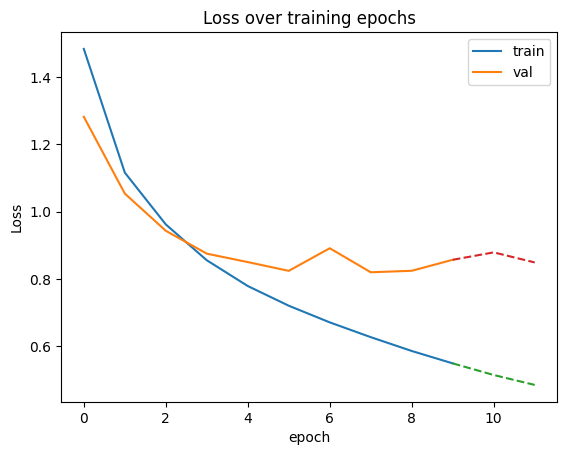

In [12]:
plt.plot(hist['train'][:(len(hist['train'])-num_epochs)])
plt.plot(hist['val'][:(len(hist['val'])-num_epochs)])
plt.plot(hist['train'][(len(hist['val'])-num_epochs-1):], linestyle='dashed')
plt.plot(hist['val'][(len(hist['val'])-num_epochs-1):], linestyle='dashed')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.title('Loss over training epochs')
plt.legend(['train','val'])
plt.show();

The model is clearly overfitting.

Overfitting is used to describe scenarios when the trained model doesn’t generalise well on unseen data but mimics the training data very well.

What are some ways we can use to fix this?

Check out the "Model Improvement" notebook to find out.

---

# Fixing the Overfit: The Day 2 Toolbox, Applied

The learning curves above told a clear story: training loss falls while validation loss climbs —
textbook **overfitting**. Yesterday we built a whole toolbox for exactly this situation. Let's apply
two of its tools to our CNN:

- **Data augmentation**: random crops and horizontal flips of the training images (a flipped cat is
  still a cat — note this *is* safe for CIFAR-10, unlike rotating MNIST digits!)
- **Dropout**: in the fully-connected head, where most of the parameters live

We'll also upgrade `train_model` to accept *any* model as an argument, so one function serves every
architecture we try.

In [13]:
# Augmentation is applied ONLY to the training set
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                 download=True, transform=train_transform)
train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


In [14]:
# Same architecture as before, plus dropout in the fully-connected head
class ConvNetV2(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 64, 3)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64*4*4, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# train_model, generalised: the model is now an argument instead of being hard-coded inside
def train_model_v2(model, train_dataset, val_dataset, num_epochs, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = dict(train=[], val=[])

    for epoch in range(num_epochs):
        model.train()
        ts = time.time()
        train_losses = []
        for images, labels in train_dataset:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in val_dataset:
                images, labels = images.to(device), labels.to(device)
                val_losses.append(criterion(model(images), labels).item())

        history['train'].append(np.mean(train_losses))
        history['val'].append(np.mean(val_losses))
        print(f"Epoch: {epoch}  train loss: {history['train'][-1]:.4f}  "
              f"val loss: {history['val'][-1]:.4f}  time: {time.time()-ts:.1f}s")

    # checkpoint with state_dicts only - works for ANY model, including pretrained ones
    # whose constructors need arguments (recreate the model first, then load_state_dict)
    checkpoint = {'epoch': num_epochs, 'state_dict': model.state_dict(),
                  'optimizer': optimizer.state_dict()}
    return model.eval(), history, checkpoint

Epoch: 0  train loss: 1.6316  val loss: 1.3255  time: 18.6s
Epoch: 1  train loss: 1.2963  val loss: 1.1642  time: 18.4s
Epoch: 2  train loss: 1.1570  val loss: 1.0273  time: 18.5s
Epoch: 3  train loss: 1.0787  val loss: 0.9245  time: 18.5s
Epoch: 4  train loss: 1.0137  val loss: 0.8649  time: 18.4s
Epoch: 5  train loss: 0.9796  val loss: 0.8754  time: 18.4s
Epoch: 6  train loss: 0.9318  val loss: 0.8025  time: 18.6s
Epoch: 7  train loss: 0.9101  val loss: 0.8275  time: 18.7s
Epoch: 8  train loss: 0.8801  val loss: 0.7918  time: 18.5s
Epoch: 9  train loss: 0.8688  val loss: 0.7777  time: 18.5s


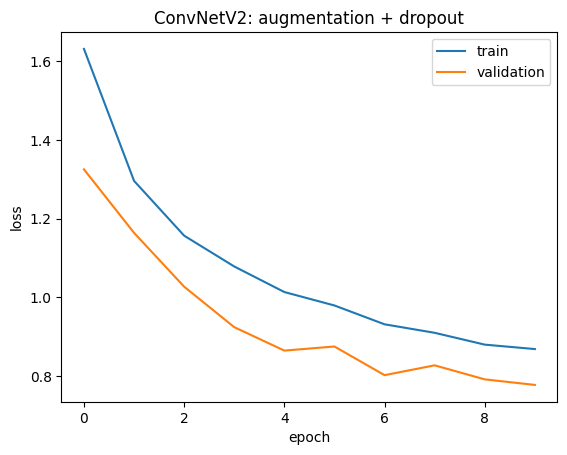

In [15]:
model_v2, history_v2, checkpoint_v2 = train_model_v2(ConvNetV2(), train_loader_aug, test_loader,
                                                     num_epochs=10)

plt.plot(history_v2['train'], label='train')
plt.plot(history_v2['val'], label='validation')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
plt.title('ConvNetV2: augmentation + dropout')
plt.show()

Compare this curve with the first one: the train/validation gap should be far smaller — the toolbox
works. (Train it for more epochs and the augmented model usually ends up *better* on validation too,
because it can train longer before overfitting.)

---

# Seeing What the Network Sees: Feature Maps

A CNN isn't a black box — we can look at the **feature maps**: the output of a convolutional layer
for a given image. Each of the 32 maps from `conv1` shows where in the image *that filter's* pattern
was found. Early layers typically light up for edges and colours; deeper layers respond to textures
and object parts.

Feature maps shape: torch.Size([1, 32, 30, 30])


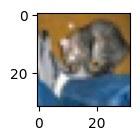

<Figure size 640x480 with 0 Axes>

In [16]:
# Pass one test image through conv1 and look at all 32 resulting feature maps
images, labels = next(iter(test_loader))
img = images[0:1].to(device)

model_v2.eval()
with torch.no_grad():
    feature_maps = F.relu(model_v2.conv1(img))    # shape: (1, 32, 30, 30)

print('Feature maps shape:', feature_maps.shape)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(5, 8, 1)
imshow(torchvision.utils.make_grid(images[0:1]))   # the input image
for i in range(32):
    ax = fig.add_subplot(5, 8, i + 9)
    ax.imshow(feature_maps[0, i].cpu(), cmap='viridis')
    ax.axis('off')
plt.suptitle(f'Input ({classes[labels[0]]}) and its 32 conv1 feature maps')
plt.show()

---

# Transfer Learning: Standing on the Shoulders of Giants

Nobody trains large vision models from scratch on small datasets. Models like **ResNet**, trained on
ImageNet (1.2 million images, 1000 classes), have already learned a rich library of visual features —
edges, textures, shapes, object parts. **Transfer learning** reuses them:

1. Load a pretrained network
2. **Freeze** its convolutional layers (keep the learned features)
3. Replace the final classification layer with one for *your* classes
4. Train only that new layer (or later, *fine-tune* everything with a small learning rate)

This typically beats training from scratch with a fraction of the data and compute. The cell below
downloads ResNet18 weights (~45 MB) the first time you run it; to keep the demo fast we train on a
subset of CIFAR-10 for a single epoch.

In [17]:
from torchvision import models
from torch.utils.data import Subset

# ResNet was trained on 224x224 ImageNet images, so we resize CIFAR images up
resnet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

resnet_train = Subset(torchvision.datasets.CIFAR10(root='./data', train=True, transform=resnet_transform),
                      range(0, 5000))
resnet_val   = Subset(torchvision.datasets.CIFAR10(root='./data', train=False, transform=resnet_transform),
                      range(0, 1000))
resnet_train_loader = torch.utils.data.DataLoader(resnet_train, batch_size=32, shuffle=True)
resnet_val_loader   = torch.utils.data.DataLoader(resnet_val, batch_size=32, shuffle=False)

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 1. freeze every pretrained layer
for param in resnet.parameters():
    param.requires_grad = False

# 2. replace the final layer (this new layer's parameters ARE trainable)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

resnet, resnet_history, _ = train_model_v2(resnet, resnet_train_loader, resnet_val_loader,
                                           num_epochs=1, lr=0.001)

Epoch: 0  train loss: 1.4179  val loss: 0.9765  time: 19.0s


In [18]:
# Accuracy of the transfer-learned model on the validation subset
n_correct, n_samples = 0, 0
resnet.eval()
with torch.no_grad():
    for images, labels in resnet_val_loader:
        images, labels = images.to(device), labels.to(device)
        _, predicted = torch.max(resnet(images), 1)
        n_correct += (predicted == labels).sum().item()
        n_samples += labels.size(0)
print(f'ResNet18 transfer learning: {100*n_correct/n_samples:.1f}% accuracy '
      f'after 1 epoch on 5,000 images')

ResNet18 transfer learning: 71.8% accuracy after 1 epoch on 5,000 images


One epoch, 5,000 images, only the last layer trained — and it usually already rivals or beats the CNN
we trained from scratch on the full 50,000. That's the power of reused features.

---

# Beyond Classification: Detection & Recognition

Everything so far answers *"what is in this image?"*. Modern CNN applications go further:

### Object Detection — *what* is in the image, and *where*?

Detectors output **bounding boxes + class labels** for every object in the scene.

- **Two-stage detectors** (e.g. **Faster R-CNN**): a CNN backbone proposes regions likely to contain
  objects, then a second stage classifies each region. Accurate, but slower.
- **One-stage detectors** (e.g. **YOLO** — "You Only Look Once", **SSD**): predict boxes and classes
  in a single pass over a grid. Fast enough for real-time video.

Both are "just" CNN backbones like the ones you built today, with extra prediction heads.

### Face Recognition — *who* is this?

Face recognition is usually **not** classification (you can't retrain a network for every new
employee!). Instead a CNN is trained to map a face to an **embedding** — a vector (e.g. 128 numbers)
where the distance between two embeddings reflects whether they're the same person:

1. **Detect** the face in the image (a small detector network, e.g. MTCNN)
2. **Embed** the cropped face with a CNN (e.g. FaceNet, trained with a *triplet loss*: pull
   same-person embeddings together, push different-person embeddings apart)
3. **Compare** to known embeddings — nearest neighbour under a distance threshold

The same embedding trick powers image search and one-shot learning generally.

The optional cell below runs a *pretrained* Faster R-CNN on any photo you give it — try one of your
own (downloads ~160 MB of weights on first run).

In [19]:
# OPTIONAL: object detection with a pretrained Faster R-CNN.
# Point IMAGE_PATH to any photo on your machine (street scenes work great), then re-run this cell.
import os
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from PIL import Image

IMAGE_PATH = 'my_photo.jpg'   # <-- change me to one of your own photos!

if not os.path.exists(IMAGE_PATH):
    print(f"No image found at '{IMAGE_PATH}'. Set IMAGE_PATH to one of your own photos and re-run "
          f"this cell to watch a pretrained detector find the objects in it.")
else:
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT   # downloads ~160 MB the first time
    detector = fasterrcnn_resnet50_fpn(weights=weights).eval()

    img = Image.open(IMAGE_PATH).convert('RGB')
    img_tensor = transforms.ToTensor()(img)

    with torch.no_grad():
        pred = detector([img_tensor])[0]

    # draw boxes for confident detections
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    labels_meta = weights.meta['categories']
    for box, label, score in zip(pred['boxes'], pred['labels'], pred['scores']):
        if score < 0.7:
            continue
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2))
        ax.text(x1, y1 - 5, f'{labels_meta[label]} {score:.2f}', color='red', fontsize=11,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.axis('off')
    plt.show()

No image found at 'my_photo.jpg'. Set IMAGE_PATH to one of your own photos and re-run this cell to watch a pretrained detector find the objects in it.


---

# Day 3 Recap & Exercises

**What you built today:** a CNN for colour images, a checkpointed training workflow, an
overfitting-resistant ConvNetV2, feature-map visualisations, a transfer-learned ResNet, and a
working object detector.

> **Going deeper:** the `extras/convolution_output_dimensions_test.ipynb` notebook walks through
> convolution/pooling output sizes layer by layer — invaluable when your `nn.Linear` input size
> doesn't match and PyTorch yells at you.

### Exercises

1. **Architecture surgery.** Add a fourth conv layer (or widen the existing ones) in `ConvNetV2`.
   Recompute the flattened size (use the extras notebook!), retrain, and compare learning curves.
2. **Filter detective.** Visualize `conv2`'s feature maps for the same image. Are they more abstract
   than `conv1`'s?
3. **Per-class accuracy.** Compute accuracy separately for each of the 10 CIFAR classes. Which pairs
   get confused most, and can you guess why?
4. **Fine-tune deeper.** In the transfer-learning model, unfreeze `layer4` of the ResNet as well and
   train with a small LR (`1e-4`). Does it beat the frozen version?
5. **(Stretch)** Run the Faster R-CNN detector on a webcam frame or a family photo. Count the
   detected objects above 0.8 confidence.

### Tomorrow: Day 4

Images are 2D space. But the world is also full of **sequences** — speech, sensor readings, time
series, text — where what comes *next* depends on what came *before*. Tomorrow: recurrent networks
and LSTMs, built to model the fourth dimension.